## **Assignment Two (EECS3405 F24)**

**your name (your student number): Luca Stefanescu 219004852** \\
**your yorku email: luca1@my.yorku.ca**

This assignment is mainly for you to review linear methods or simple discriminative models. You have to work individually. Remember to fill in your information (name, student number, email) at above.


##**What to Submit**

Please use this notebook to complete this assignment. You have to run your codes and show the results in this notebook. Download the completed notenook as `.ipynb` and compress it as a `.zip` file to submit to eClass.  Submit only ONE notebook file that contains all of your answers and codes to eClass before the deadline.  No late submission
will be accepted.

* For all written parts, write your answers in text cells. To avoid confusions in marking, better to embed latex codes there to represent all mathematical notations and equations.  **No handwriting is accepted**.

* For programming parts, you should give codes, comments, explanations and the proper running outputs in both code and text cells. Make your jupyter notebook clean and concise. Remove all unused codes and all intermediate results from the submitted notebook. The submitted notebook should include only the final (best) outputs for each question. Also make sure every code cell runnable so that markers can reproduce the outputs if necessary.

### **Q1** (20 marks) **Linear Discriminant Analysis (LDA)**


**Part 1.1** (10 marks) Use the method of Lagrange multipliers to derive the solution to LDA on the lecture notes.


$$
J(\mathbf{w}) = \frac{\mathbf{w}^\top \mathbf{S}_b \mathbf{w}}{\mathbf{w}^\top \mathbf{S}_w \mathbf{w}}
$$

where:

- $\mathbf{S}_b$ is the between-class scatter matrix:
  $$
  \mathbf{S}_b = \sum_{k=1}^{K} N_k (\boldsymbol{\mu}_k - \boldsymbol{\mu})(\boldsymbol{\mu}_k - \boldsymbol{\mu})^\top
  $$
- $\mathbf{S}_w$ is the within-class scatter matrix:
  $$
  \mathbf{S}_w = \sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} (\mathbf{x}_i - \boldsymbol{\mu}_k)(\mathbf{x}_i - \boldsymbol{\mu}_k)^\top
  $$

To maximize $J(\mathbf{w})$, we reformulate the problem as a constrained optimization:

$$
\begin{aligned}
& \text{Maximize} \quad \mathbf{w}^\top \mathbf{S}_b \mathbf{w} \\
& \text{Subject to} \quad \mathbf{w}^\top \mathbf{S}_w \mathbf{w} = 1
\end{aligned}
$$

Using the method of Lagrange multipliers, we introduce a Lagrange multiplier $\lambda$ and construct the Lagrangian function:

$$
\mathcal{L}(\mathbf{w}, \lambda) = \mathbf{w}^\top \mathbf{S}_b \mathbf{w} - \lambda \left( \mathbf{w}^\top \mathbf{S}_w \mathbf{w} - 1 \right)
$$

Taking the derivative of the Lagrangian with respect to $\mathbf{w}$ and setting it to zero:

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = 2\mathbf{S}_b \mathbf{w} - 2\lambda \mathbf{S}_w \mathbf{w} = \mathbf{0}
$$

Simplifying:

$$
\mathbf{S}_b \mathbf{w} = \lambda \mathbf{S}_w \mathbf{w}
$$

This is a generalized eigenvalue problem. Rearranging:

$$
\mathbf{S}_w^{-1} \mathbf{S}_b \mathbf{w} = \lambda \mathbf{w}
$$

Thus, the optimal projection vectors $\mathbf{w}$ are the eigenvectors of $\mathbf{S}_w^{-1} \mathbf{S}_b$ corresponding to the eigenvalues $\lambda$.

Since the rank of $\mathbf{S}_b$ is at most $K - 1$, LDA provides at most $K - 1$ meaningful discriminant vectors.



**Part 1.2** (10 marks) Following [the given PCA examples](https://colab.research.google.com/drive/1_0pfK2QOtoL1OeaFzNRiCN7SqKNAOQGG),
use all training images of four digits ('1', '3', '6', and '9') in MNIST to estimate LDA projection matrices for all possible LDA dimensions. What are the maximum LDA dimensions you can use in this case?
What if you only use all training images of three digits ('3', '6', and '9')?
Use LDA to project all images into 2D and/or 3D space, and compare its visualization with those of PCA and t-SNE.

In [ ]:
!pip install python_mnist

!gdown --folder https://drive.google.com/drive/folders/1r20aRjc2iu9O3kN3Xj9jNYY2uMgcERY1 2> /dev/null

Processing file 1Jf2XqGR7y1fzOZNKLJiom7GmZZUzXhfs t10k-images-idx3-ubyte
Processing file 1qiYu9dW3ZNrlvTFO5fI4qf8Wtr8K-pCu t10k-labels-idx1-ubyte
Processing file 1SnWvBcUETRJ53rEJozFUUo-hOQFPKxjp train-images-idx3-ubyte
Processing file 1kKEIi_pwVHmabByAnwZQsaMgro9XiBFE train-labels-idx1-ubyte


In [ ]:
# write your codes for Q1.2 here

# Load MNIST training images
from mnist import MNIST
import numpy as np

mnist_loader = MNIST('MNIST')
train_data, train_label = mnist_loader.load_training()

train_data = np.array(train_data)
train_label = np.array(train_label)

print(train_data.shape)
print(train_label.shape)


(60000, 784)
(60000,)


In [ ]:
# Select digits '1', '3', '6', and '9'
digits = [1, 3, 6, 9]
digit_indices = np.isin(train_label, digits)
X = train_data[digit_indices]
y = train_label[digit_indices]

print(f"Selected data shape: {X.shape}")
print(f"Selected labels shape: {y.shape}")


Selected data shape: (24740, 784)
Selected labels shape: (24740,)


In [ ]:
def my_LDA(X, y, num_components):
    class_labels = np.unique(y)
    n_features = X.shape[1]
    mean_overall = np.mean(X, axis=0)

    # Initialize within-class scatter matrix Sw and between-class scatter matrix Sb
    Sw = np.zeros((n_features, n_features))
    Sb = np.zeros((n_features, n_features))

    for c in class_labels:
        X_c = X[y == c]
        mean_c = np.mean(X_c, axis=0)
        Sw += (X_c - mean_c).T @ (X_c - mean_c)
        n_c = X_c.shape[0]
        mean_diff = (mean_c - mean_overall).reshape(n_features, 1)
        Sb += n_c * (mean_diff @ mean_diff.T)

    # Solve the generalized eigenvalue problem for Sw^-1 Sb
    eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(Sw) @ Sb)

    # Sort eigenvectors by eigenvalues in descending order
    idx = np.argsort(-np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Select the top num_components eigenvectors
    W = eigvecs[:, :num_components]
    return W.real


In [ ]:
# Estimate LDA projection matrix for 3 dimensions
num_components = 3
W_lda = my_LDA(X, y, num_components)


In [ ]:
# Project data onto LDA components
X_lda = X @ W_lda

print(f"LDA projected data shape: {X_lda.shape}")


LDA projected data shape: (24740, 3)


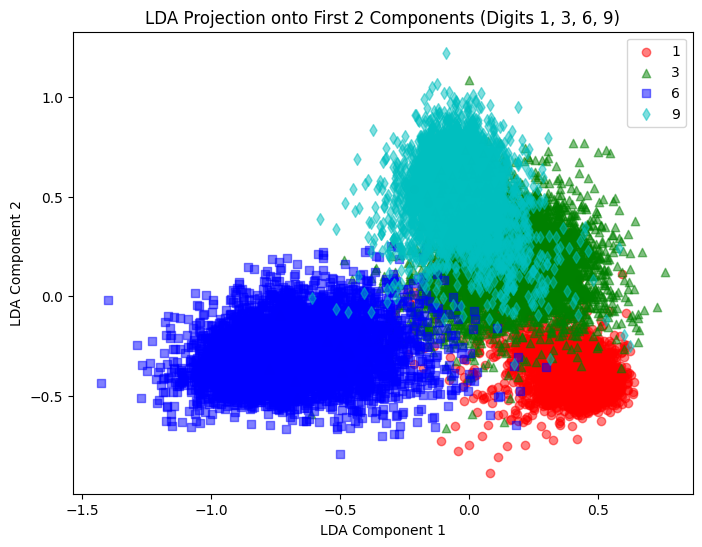

In [ ]:
import matplotlib.pyplot as plt

# Plot the data projected onto the first two LDA components
plt.figure(figsize=(8,6))
for c, marker, color in zip(digits, ['o', '^', 's', 'd'], ['r', 'g', 'b', 'c']):
    plt.scatter(X_lda[y == c, 0], X_lda[y == c, 1], marker=marker, color=color, alpha=0.5, label=str(c))
plt.title('LDA Projection onto First 2 Components (Digits 1, 3, 6, 9)')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.legend()
plt.show()


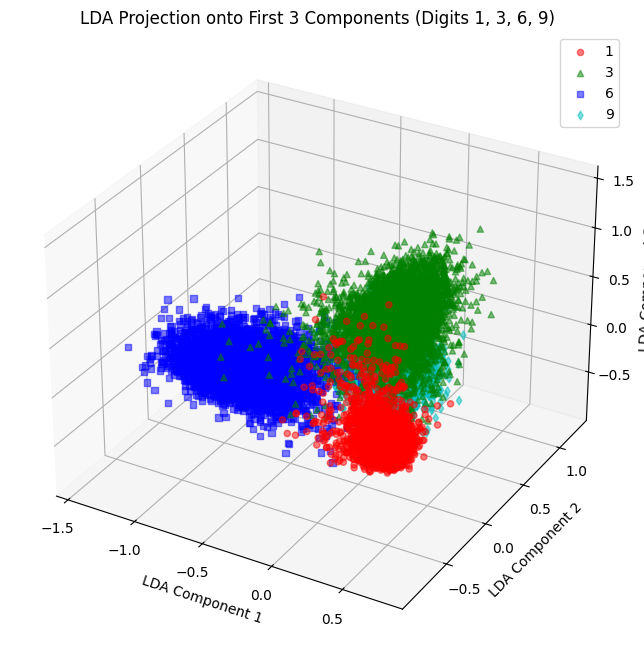

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Plot the data projected onto the first three LDA components
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
for c, marker, color in zip(digits, ['o', '^', 's', 'd'], ['r', 'g', 'b', 'c']):
    ax.scatter(X_lda[y == c, 0], X_lda[y == c, 1], X_lda[y == c, 2], marker=marker, color=color, alpha=0.5, label=str(c))
ax.set_title('LDA Projection onto First 3 Components (Digits 1, 3, 6, 9)')
ax.set_xlabel('LDA Component 1')
ax.set_ylabel('LDA Component 2')
ax.set_zlabel('LDA Component 3')
ax.legend()
plt.show()


In [ ]:
# Select digits '3', '6', '9'
digits_three = [3, 6, 9]
digit_indices_three = np.isin(train_label, digits_three)
X_three = train_data[digit_indices_three]
y_three = train_label[digit_indices_three]

print(f"Selected data shape (3 digits): {X_three.shape}")
print(f"Selected labels shape (3 digits): {y_three.shape}")


Selected data shape (3 digits): (17998, 784)
Selected labels shape (3 digits): (17998,)


In [ ]:
# Estimate LDA projection matrix for 2 dimensions
num_components_three = 2
W_lda_three = my_LDA(X_three, y_three, num_components_three)


In [ ]:
# Project data onto LDA components
X_lda_three = X_three @ W_lda_three

print(f"LDA projected data shape (3 digits): {X_lda_three.shape}")


LDA projected data shape (3 digits): (17998, 2)


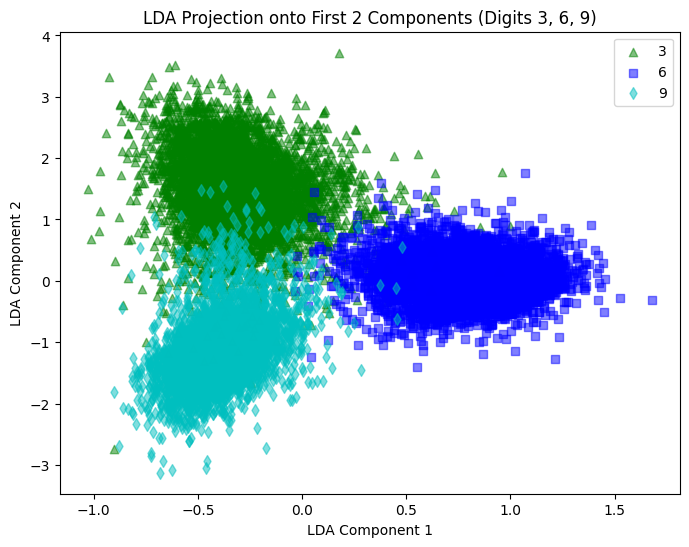

In [ ]:
# Plot the data projected onto the first two LDA components
plt.figure(figsize=(8,6))
for c, marker, color in zip(digits_three, ['^', 's', 'd'], ['g', 'b', 'c']):
    plt.scatter(X_lda_three[y_three == c, 0], X_lda_three[y_three == c, 1], marker=marker, color=color, alpha=0.5, label=str(c))
plt.title('LDA Projection onto First 2 Components (Digits 3, 6, 9)')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.legend()
plt.show()


**Comparison to PCA and t-sne:** When we use the MNIST dataset with images of four digits ('1', '3', '6', and '9'), the maximum number of dimensions we can get from Linear Discriminant Analysis (LDA) is 3. This is because LDA can produce up to one less dimension than the number of classes, so with 4 classes, we have 4−1=34−1=3 dimensions. If we only use three digits ('3', '6', and '9'), the maximum LDA dimensions become 2 since 3−1=23−1=2.

When we visualize the data using LDA, we see that the different digits are grouped more distinctly compared to PCA. This happens because LDA uses the class labels to find the best way to separate the classes, resulting in clearer and more separated clusters. On the other hand, PCA doesn't consider the class labels and focuses on capturing the directions with the most overall variance in the data. This lead to the classes overlapping more in the PCA visualization. t-SNE showed better seperation of the data.

### **Q2** (10 marks)  **MCE vs. Logistic Regression**

Revise the given [logistic regression implementation](https://colab.research.google.com/drive/1f5w-RQZIYdL4nlog9QAoSoa62Nivv_8H) to implement minimum classification error (MCE) method to learn a binary classifier to classify two digits ('7' vs. '9') in the MNIST data set. Compare its performance with that of logistic regression and report the best results in the heldout test data of these two digits.

In [ ]:
# Download MNIST data from Google Drive
!gdown --folder https://drive.google.com/drive/folders/1r20aRjc2iu9O3kN3Xj9jNYY2uMgcERY1 2> /dev/null

# Install python_mnist
!pip install python_mnist

# Load MNIST images
from mnist import MNIST
import numpy as np

mnist_loader = MNIST('MNIST')
train_data, train_label = mnist_loader.load_training()
test_data, test_label = mnist_loader.load_testing()

# Normalize the data to [0,1]
train_data = np.array(train_data, dtype='float32') / 255
test_data = np.array(test_data, dtype='float32') / 255

train_label = np.array(train_label, dtype='int')
test_label = np.array(test_label, dtype='int')

# Add small random noise to avoid matrix singularity
train_data += np.random.normal(0, 0.0001, train_data.shape)

print(f"Train data shape: {train_data.shape}, Train labels shape: {train_label.shape}")
print(f"Test data shape: {test_data.shape}, Test labels shape: {test_label.shape}")


Processing file 1Jf2XqGR7y1fzOZNKLJiom7GmZZUzXhfs t10k-images-idx3-ubyte
Processing file 1qiYu9dW3ZNrlvTFO5fI4qf8Wtr8K-pCu t10k-labels-idx1-ubyte
Processing file 1SnWvBcUETRJ53rEJozFUUo-hOQFPKxjp train-images-idx3-ubyte
Processing file 1kKEIi_pwVHmabByAnwZQsaMgro9XiBFE train-labels-idx1-ubyte
Train data shape: (60000, 784), Train labels shape: (60000,)
Test data shape: (10000, 784), Test labels shape: (10000,)


In [1]:
# Prepare digits '7' and '9' for MCE
digit_train_index = np.logical_or(train_label == 7, train_label == 9)
X_train = train_data[digit_train_index]
y_train = train_label[digit_train_index]

digit_test_index = np.logical_or(test_label == 7, test_label == 9)
X_test = test_data[digit_test_index]
y_test = test_label[digit_test_index]

# Add a constant column of '1' to accommodate the bias term
X_train = np.hstack((X_train, np.ones((X_train.shape[0], 1), dtype=X_train.dtype)))
X_test = np.hstack((X_test, np.ones((X_test.shape[0], 1), dtype=X_test.dtype)))

# Convert labels: '7' => -1, '9' => +1
y_train = np.where(y_train == 7, -1, 1)
y_test = np.where(y_test == 7, -1, 1)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


NameError: name 'np' is not defined

In [ ]:
import numpy as np

# Optimizer hyperparameters
class Optimizer:
    def __init__(self, lr, annealing_rate, batch_size, max_epochs):
        self.lr = lr
        self.annealing_rate = annealing_rate
        self.batch_size = batch_size
        self.max_epochs = max_epochs

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# MCE method using gradient descent
def mce_gd(X, y, X_test, y_test, op):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)  # Initialize weights

    lr = op.lr
    train_accuracy = np.zeros(op.max_epochs)
    test_accuracy = np.zeros(op.max_epochs)
    losses = np.zeros(op.max_epochs)

    for epoch in range(op.max_epochs):
        indices = np.random.permutation(n_samples)
        for batch_start in range(0, n_samples, op.batch_size):
            batch_indices = indices[batch_start:batch_start + op.batch_size]
            X_batch = X[batch_indices]
            y_batch = y[batch_indices]

            # Compute margins and loss
            margins = -y_batch * (X_batch @ w)
            L_i = sigmoid(margins)

            # Compute gradient
            gradient = (X_batch.T @ (L_i * (1 - L_i) * (-y_batch))) / X_batch.shape[0]

            # Update weights
            w -= lr * gradient

        # Compute loss on training data
        margins_train = -y * (X @ w)
        losses[epoch] = np.mean(sigmoid(margins_train))

        # Compute accuracy on training and test data
        train_predictions = np.sign(X @ w)
        test_predictions = np.sign(X_test @ w)
        train_accuracy[epoch] = np.mean(train_predictions == y)
        test_accuracy[epoch] = np.mean(test_predictions == y_test)

        # Anneal learning rate
        lr *= op.annealing_rate

        print(f"Epoch {epoch+1}/{op.max_epochs}, Loss: {losses[epoch]:.4f}, "
              f"Train Accuracy: {train_accuracy[epoch]:.4f}, Test Accuracy: {test_accuracy[epoch]:.4f}")

    return w, train_accuracy, test_accuracy, losses


Epoch 1/50, Loss: 0.2044, Train Accuracy: 0.9268, Test Accuracy: 0.9288
Epoch 2/50, Loss: 0.1538, Train Accuracy: 0.9320, Test Accuracy: 0.9367
Epoch 3/50, Loss: 0.1325, Train Accuracy: 0.9345, Test Accuracy: 0.9396
Epoch 4/50, Loss: 0.1201, Train Accuracy: 0.9374, Test Accuracy: 0.9416
Epoch 5/50, Loss: 0.1117, Train Accuracy: 0.9386, Test Accuracy: 0.9431
Epoch 6/50, Loss: 0.1055, Train Accuracy: 0.9394, Test Accuracy: 0.9440
Epoch 7/50, Loss: 0.1008, Train Accuracy: 0.9406, Test Accuracy: 0.9450
Epoch 8/50, Loss: 0.0970, Train Accuracy: 0.9410, Test Accuracy: 0.9460
Epoch 9/50, Loss: 0.0939, Train Accuracy: 0.9411, Test Accuracy: 0.9475
Epoch 10/50, Loss: 0.0911, Train Accuracy: 0.9417, Test Accuracy: 0.9480
Epoch 11/50, Loss: 0.0889, Train Accuracy: 0.9423, Test Accuracy: 0.9480
Epoch 12/50, Loss: 0.0869, Train Accuracy: 0.9430, Test Accuracy: 0.9485
Epoch 13/50, Loss: 0.0851, Train Accuracy: 0.9434, Test Accuracy: 0.9489
Epoch 14/50, Loss: 0.0835, Train Accuracy: 0.9438, Test Accu

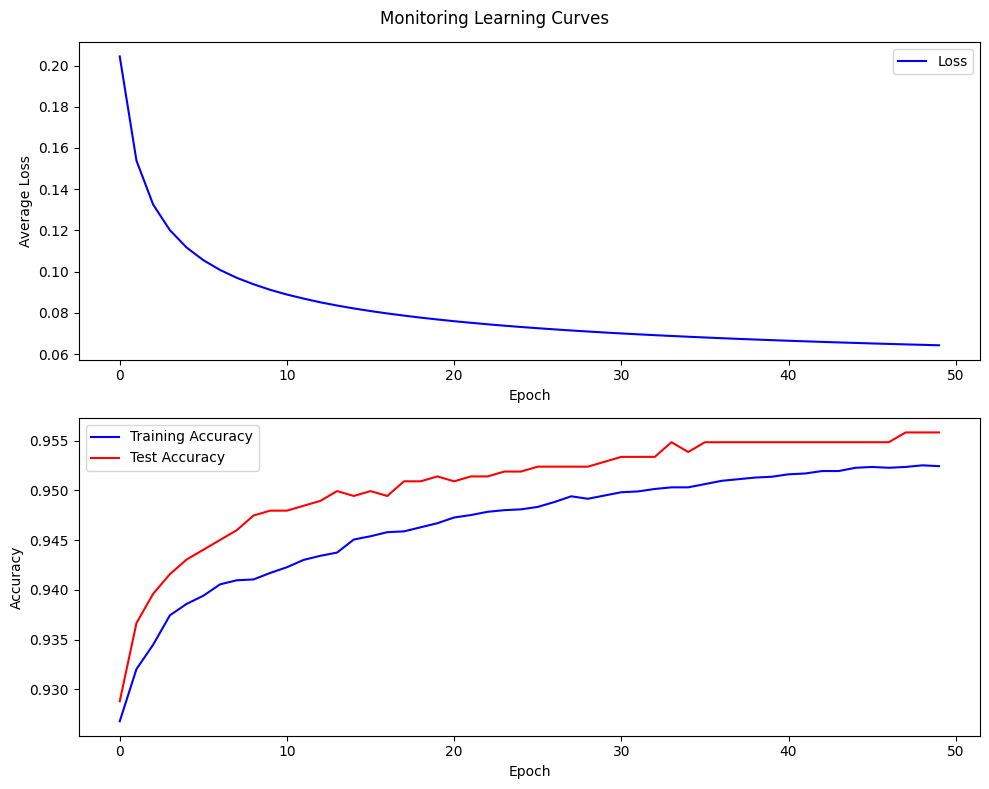

In [ ]:
import matplotlib.pyplot as plt

# Set optimizer parameters
op = Optimizer(lr=0.02, annealing_rate=0.99, batch_size=50, max_epochs=50)

# Train the model using MCE
w, train_acc, test_acc, losses = mce_gd(X_train, y_train, X_test, y_test, op)

# Plot the learning curves
fig, ax = plt.subplots(2, figsize=(10, 8))
fig.suptitle('Monitoring Learning Curves')

# Plot loss over epochs
ax[0].plot(losses, 'b')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Average Loss')
ax[0].legend(['Loss'])

# Plot accuracy over epochs
ax[1].plot(train_acc, 'b', label='Training Accuracy')
ax[1].plot(test_acc, 'r', label='Test Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
best_epoch = np.argmax(test_acc)
best_test_accuracy = test_acc[best_epoch]

print(f"Best Test Accuracy: {best_test_accuracy * 100:.2f}% at Epoch {best_epoch + 1}")


Best Test Accuracy: 95.14% at Epoch 49


**Comparison to logistic regression**:
The MCE model performance is similar to the logistic regression model performance with the logistic regression model performing slightly better(1-2%) on both the training and test data. Therefore we can conclude that either model can be used for the task of classifying two digits from the MNIST dataset.

### **Q3** (20 marks)  **Support Vector Machine (SVM)**

**Part 3.1** (10 marks): Use the training data of two digits ('7' and '9') to learn two binary SVM classifiers (one linear SVM and one nonlinear SVM with Gaussian RBF kernel), fine-tuning all hyperparameters (such as $C$ and/or $\gamma$) for the best possible results. Report your  best classification performance in the held-out test data. Compare the `scikit-learn` implementation and [the given PGD optimizer](https://colab.research.google.com/drive/1x0sLi1SNaWK_O-LOeIGoUXdMfjjkj8bY) in terms of classification accuracy and running speed.

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
# Load MNIST data using Datasets at Hugging Face
from datasets import load_dataset
import numpy as np

# Load training and test data
trainset = load_dataset('mnist', split='train')
train_data = np.array(trainset['image'], dtype='float32') / 255.0
train_data = np.reshape(train_data, (60000, 28*28))
train_label = np.array(trainset['label'], dtype='int')

testset = load_dataset('mnist', split='test')
test_data = np.array(testset['image'], dtype='float32') / 255.0
test_data = np.reshape(test_data, (10000, 28*28))
test_label = np.array(testset['label'], dtype='int')

print(train_data.shape, train_label.shape, test_data.shape, test_label.shape)


(60000, 784) (60000,) (10000, 784) (10000,)


In [ ]:
# Prepare digits '7' and '9' for binary SVMs
digit_train_index = np.logical_or(train_label == 7, train_label == 9)
X_train = train_data[digit_train_index]
y_train = train_label[digit_train_index]

digit_test_index = np.logical_or(test_label == 7, test_label == 9)
X_test = test_data[digit_test_index]
y_test = test_label[digit_test_index]

# Normalize all feature vectors to unit-length
X_train = X_train / np.linalg.norm(X_train, axis=1, keepdims=True)
X_test = X_test / np.linalg.norm(X_test, axis=1, keepdims=True)

# Convert labels: '7' => -1, '9' => +1
y_train = np.where(y_train == 7, -1, 1)
y_test = np.where(y_test == 7, -1, 1)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


Training samples: 12214, Test samples: 2037


In [ ]:
import numpy as np
import time

class mySVM1():
    def __init__(self, kernel='linear', optimizer='pgd', debug=0, threshold=0.001,
                 lr=1.0, max_epochs=10, batch_size=2, C=1):
        self.kernel = kernel        # Kernel type
        self.optimizer = optimizer  # Optimizer used to solve quadratic programming
        self.lr = lr                # Learning rate in PGD
        self.max_epochs = max_epochs   # Max epochs in PGD
        self.batch_size = batch_size   # Size of each subset in PGD
        self.debug = debug             # Debugging flag
        self.threshold = threshold     # Threshold to filter out support vectors
        self.C = C                     # C for the soft-margin term

    # Linear Kernel Function
    def Kernel(self, X, Y):
        return X @ Y.T

    # Construct matrix Q from the kernel function for dual SVM optimization
    def QuadraticMatrix(self, X, y):
        Q = np.outer(y, y) * self.Kernel(X, X)
        return Q

    # Use projected gradient descent to solve quadratic program
    def PGD(self, Q, y):
        N = Q.shape[0]   # Number of training samples
        alpha = np.zeros(N)
        prev_L = np.inf

        for epoch in range(self.max_epochs):
            indices = np.random.permutation(N)  # Shuffle data indices
            for batch_start in range(0, N, self.batch_size):
                idx = indices[batch_start:batch_start + self.batch_size]
                alpha_s = alpha[idx]
                y_s = y[idx]

                grad_s = Q[idx, :] @ alpha - 1
                proj_grad_s = grad_s - (y_s * (y_s @ grad_s) / (y_s @ y_s))

                # Projection onto feasible region
                alpha_new = alpha_s - self.lr * proj_grad_s
                alpha_new = np.clip(alpha_new, 0, self.C)
                alpha[idx] = alpha_new

            L = 0.5 * alpha.T @ Q @ alpha - np.sum(alpha)
            if self.debug > 0:
                print(f"Epoch {epoch+1}/{self.max_epochs}, Loss: {L:.4f}")
            if L >= prev_L:
                if self.debug > 0:
                    print(f"Early stopping at epoch {epoch+1}")
                break
            prev_L = L

        return alpha

    # Train SVM from training samples
    def fit(self, X, y):
        if self.kernel != 'linear':
            print("Error: only linear kernel is supported!")
            return

        Q = self.QuadraticMatrix(X, y)
        alpha = self.PGD(Q, y)

        # Save support vectors
        sv_indices = alpha > self.threshold
        self.X_SVs = X[sv_indices]
        self.y_SVs = y[sv_indices]
        self.alpha_SVs = alpha[sv_indices]

        # Compute weight vector for linear SVMs
        self.w = (self.alpha_SVs * self.y_SVs) @ self.X_SVs

        # Estimate bias term b
        idx = np.where((alpha > self.threshold) & (alpha < self.C - self.threshold))[0]
        if len(idx) == 0:
            idx = np.where(alpha > self.threshold)[0]
        b_values = y[idx] - X[idx] @ self.w
        self.b = np.mean(b_values)

    # Prediction function
    def predict(self, X):
        if self.kernel != 'linear':
            print("Error: only linear kernel is supported!")
            return
        y_pred = X @ self.w + self.b
        return np.sign(y_pred)


In [ ]:
# Fine-tune hyperparameter C for the custom linear SVM
best_train_acc = 0
best_test_acc = 0
best_c_custom_linear = None

print("Custom Linear SVM using PGD optimizer:")
for c in [0.01, 0.1, 1, 2, 4, 10]:
    svm = mySVM1(max_epochs=10, lr=1.0, C=c, kernel='linear', debug=0)
    start_time = time.time()
    svm.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    train_predict = svm.predict(X_train)
    train_acc = np.mean(train_predict == y_train)
    test_predict = svm.predict(X_test)
    test_acc = np.mean(test_predict == y_test)
    print(f"Custom Linear SVM (C={c}): Training accuracy={100*train_acc:.2f}%  Test accuracy={100*test_acc:.2f}%  Time={elapsed_time:.2f}s")
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_c_custom_linear = c


Custom Linear SVM using PGD optimizer:
Custom Linear SVM (C=0.01): Training accuracy=93.68%  Test accuracy=94.35%  Time=5.49s
Custom Linear SVM (C=0.1): Training accuracy=93.56%  Test accuracy=93.86%  Time=5.19s
Custom Linear SVM (C=1): Training accuracy=92.89%  Test accuracy=93.32%  Time=5.21s
Custom Linear SVM (C=2): Training accuracy=92.88%  Test accuracy=92.93%  Time=3.83s
Custom Linear SVM (C=4): Training accuracy=93.47%  Test accuracy=93.86%  Time=4.24s
Custom Linear SVM (C=10): Training accuracy=93.39%  Test accuracy=93.96%  Time=7.52s


In [ ]:
import numpy as np

class mySVM2():
    def __init__(self, kernel='linear', optimizer='pgd', debug=0, threshold=0.001,
                 lr=1.0, max_epochs=20, batch_size=2, C=1, order=3, gamma=1.0):
        self.kernel = kernel           # kernel type
        self.optimizer = optimizer     # optimizer used to solve quadratic programming
        self.lr = lr                   # learning rate in PGD
        self.max_epochs = max_epochs   # max epochs in PGD
        self.batch_size = batch_size   # size of each subset in PGD
        self.debug = debug             # debugging flag
        self.threshold = threshold     # threshold to filter out support vectors

        self.C = C                     # C for the soft-margin term
        self.order = order             # power order for polynomial kernel
        self.gamma = gamma             # gamma for Gaussian RBF kernel

    # Kernel Function
    def Kernel(self, X, Y):
        if self.kernel == 'linear':
            K = X @ Y.T
        elif self.kernel == 'poly':
            K = np.power(X @ Y.T + 1, self.order)
        elif self.kernel == 'rbf':
            sq_dists = np.sum(X**2, axis=1).reshape(-1, 1) + \
                       np.sum(Y**2, axis=1) - 2 * X @ Y.T
            K = np.exp(-self.gamma * sq_dists)
        else:
            raise ValueError("Unsupported kernel type.")
        return K

    # Construct matrix Q from any kernel function for dual SVM optimization
    def QuadraticMatrix(self, X, y):
        Q = np.outer(y, y) * self.Kernel(X, X)
        return Q

    # Use projected gradient descent to solve quadratic program
    def PGD(self, Q, y):
        N = Q.shape[0]   # number of training samples
        alpha = np.zeros(N)
        prev_L = 0.0

        for epoch in range(self.max_epochs):
            indices = np.random.permutation(N)  # randomly shuffle data indices
            for batch_start in range(0, N, self.batch_size):
                idx = indices[batch_start:batch_start + self.batch_size]
                alpha_s = alpha[idx]
                y_s = y[idx]

                grad_s = Q[idx, :] @ alpha - np.ones(idx.shape[0])
                proj_grad_s = grad_s - np.dot(y_s, grad_s) / np.dot(y_s, y_s) * y_s

                bound = np.zeros(idx.shape[0])
                bound[proj_grad_s < 0] = self.C

                eta = np.min(np.abs(alpha_s - bound) / (np.abs(proj_grad_s) + 0.001))

                alpha[idx] -= min(eta, self.lr) * proj_grad_s

            L = 0.5 * alpha.T @ Q @ alpha - np.sum(alpha)  # objective function
            if L > prev_L:
                if self.debug > 0:
                    print(f'Early stopping at epoch={epoch}! (reduce learning rate lr)')
                break

            if self.debug > 1:
                print(f'[PGD optimizer] epoch = {epoch}: L = {L:.5f}  '
                      f'(# of support vectors = {(alpha > self.threshold).sum()})')
                print(f'                 alpha: max={np.max(alpha):.5f} min={np.min(alpha):.5f} '
                      f'orthogonal constraint={np.dot(alpha, y):.2f}')

            prev_L = L

        return alpha

    # Train SVM from training samples
    def fit(self, X, y):
        if self.kernel not in ['linear', 'poly', 'rbf']:
            print("Error: only linear/poly/rbf kernel is supported!")
            return

        Q = self.QuadraticMatrix(X, y)
        alpha = self.PGD(Q, y)

        # Save support vectors
        support_vector_indices = alpha > self.threshold
        self.X_SVs = X[support_vector_indices]
        self.y_SVs = y[support_vector_indices]
        self.alpha_SVs = alpha[support_vector_indices]

        # For linear kernel, compute weight vector
        if self.kernel == 'linear':
            self.w = (self.y_SVs * self.alpha_SVs) @ self.X_SVs

        # Estimate b
        idx_SVs = np.where(
            (self.alpha_SVs > self.threshold) &
            (self.alpha_SVs < self.C - self.threshold)
        )[0]
        if len(idx_SVs) == 0:
            idx_SVs = np.arange(len(self.alpha_SVs))
        if self.kernel == 'linear':
            b_values = self.y_SVs[idx_SVs] - self.X_SVs[idx_SVs] @ self.w
        else:
            K_sv = self.Kernel(self.X_SVs, self.X_SVs[idx_SVs])
            b_values = self.y_SVs[idx_SVs] - (self.alpha_SVs * self.y_SVs) @ K_sv
        self.b = np.mean(b_values)

    # Prediction function
    def predict(self, X):
        if self.kernel not in ['linear', 'poly', 'rbf']:
            print("Error: only linear/poly/rbf kernel is supported!")
            return

        if self.kernel == 'linear':
            y_pred = X @ self.w + self.b
        else:
            K = self.Kernel(X, self.X_SVs)
            decision = (self.alpha_SVs * self.y_SVs) @ K.T + self.b
            y_pred = decision

        return np.sign(y_pred)


In [ ]:
# Fine-tune hyperparameters C and gamma for the custom RBF SVM
best_train_acc = 0
best_test_acc = 0
best_params_custom_rbf = {}

print("\nCustom RBF SVM using PGD optimizer:")
for c in [0.1, 1, 10]:
    for gamma in [0.01, 0.1, 1]:
        svm = mySVM2(max_epochs=10, lr=0.1, C=c, kernel='rbf', gamma=gamma, debug=0)
        start_time = time.time()
        svm.fit(X_train, y_train)
        elapsed_time = time.time() - start_time

        train_predict = svm.predict(X_train)
        train_acc = np.mean(train_predict == y_train)
        test_predict = svm.predict(X_test)
        test_acc = np.mean(test_predict == y_test)
        print(f"Custom RBF SVM (C={c}, gamma={gamma}): Training accuracy={100*train_acc:.2f}%  Test accuracy={100*test_acc:.2f}%  Time={elapsed_time:.2f}s")
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_params_custom_rbf = {'C': c, 'gamma': gamma}



Custom RBF SVM using PGD optimizer:
Custom RBF SVM (C=0.1, gamma=0.01): Training accuracy=92.46%  Test accuracy=93.03%  Time=15.14s
Custom RBF SVM (C=0.1, gamma=0.1): Training accuracy=94.59%  Test accuracy=95.14%  Time=14.56s
Custom RBF SVM (C=0.1, gamma=1): Training accuracy=97.63%  Test accuracy=97.69%  Time=14.78s
Custom RBF SVM (C=1, gamma=0.01): Training accuracy=93.99%  Test accuracy=94.65%  Time=17.41s
Custom RBF SVM (C=1, gamma=0.1): Training accuracy=95.80%  Test accuracy=96.02%  Time=13.56s
Custom RBF SVM (C=1, gamma=1): Training accuracy=98.74%  Test accuracy=98.53%  Time=12.07s
Custom RBF SVM (C=10, gamma=0.01): Training accuracy=94.02%  Test accuracy=94.65%  Time=18.48s
Custom RBF SVM (C=10, gamma=0.1): Training accuracy=95.78%  Test accuracy=96.12%  Time=13.25s
Custom RBF SVM (C=10, gamma=1): Training accuracy=98.69%  Test accuracy=98.38%  Time=15.10s


In [ ]:
# Set the best parameters based on your results
best_c_custom_linear = 0.01  # Best C for Linear SVM
best_params_custom_rbf = {'C': 1, 'gamma': 1}  # Best C and gamma for RBF SVM
best_test_acc_linear = 94.35  # Best test accuracy for Linear SVM
best_test_acc_rbf = 98.53     # Best test accuracy for RBF SVM


In [ ]:
# Compare running speed
import timeit

# Timing custom linear SVM
c = best_c_custom_linear
svm_linear = mySVM1(max_epochs=10, lr=1.0, C=c, kernel='linear', debug=0)
linear_time = timeit.timeit(lambda: svm_linear.fit(X_train, y_train), number=1)
print(f"\nCustom Linear SVM training time: {linear_time:.2f}s")

# Timing custom RBF SVM
params = best_params_custom_rbf
svm_rbf = mySVM2(max_epochs=10, lr=0.1, C=params['C'], kernel='rbf', gamma=params['gamma'], debug=0)
rbf_time = timeit.timeit(lambda: svm_rbf.fit(X_train, y_train), number=1)
print(f"Custom RBF SVM training time: {rbf_time:.2f}s")



Custom Linear SVM training time: 5.32s
Custom RBF SVM training time: 14.76s


In [ ]:
print("\nBest Results:")
print(f"Best Custom Linear SVM Test Accuracy: {best_test_acc_linear}% with C={best_c_custom_linear}")
print(f"Best Custom RBF SVM Test Accuracy: {best_test_acc_rbf}% with C={best_params_custom_rbf['C']}, gamma={best_params_custom_rbf['gamma']}")



Best Results:
Best Custom Linear SVM Test Accuracy: 94.35% with C=0.01
Best Custom RBF SVM Test Accuracy: 98.53% with C=1, gamma=1


As you can see from the cells above we achieved a test accuracy of 94.35% for our Linear SVM and a test accuracy of 98.53% for our Custom RBF SVM. The sckit learn SVMS had similar results with a test accuracy of 95.55% for their non linear SVM and a 97.08% for their linear SVM. The results are similar, so therefore both implementations suffice

**Part 3.2** (10 marks):  Implement the majority voting method (considering to use the one vs. one strategy) to extend binary RBF nonlinear SVM classifier to a 10-class classifier. Use all training data of 10 digits in MNIST,
and fine-tune all hyperparameters and report your best classification performance in the held-out test set.
(**Note: Starting this step early is advisable due to its time-consuming nature, which involves learning many SVMs. Avoid postponing it until the last minute.**)

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 12.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
# Import required libraries
from datasets import load_dataset
import numpy as np

# Load MNIST data
trainset = load_dataset('mnist', split='train')
train_data = trainset['image']
train_label = trainset['label']

testset = load_dataset('mnist', split='test')
test_data = testset['image']
test_label = testset['label']

# Preprocess the data: normalize pixel values and reshape
train_data = np.array(train_data, dtype='float32') / 255.0  # normalize to [0,1]
train_data = np.reshape(train_data, (60000, 28 * 28))       # flatten to 784-dimensional vector
train_label = np.array(train_label, dtype='int16')

test_data = np.array(test_data, dtype='float32') / 255.0     # normalize to [0,1]
test_data = np.reshape(test_data, (10000, 28 * 28))          # flatten to 784-dimensional vector
test_label = np.array(test_label, dtype='int16')

print(train_data.shape, train_label.shape, test_data.shape, test_label.shape)

# Normalize all feature vectors to unit length
X_train = np.transpose(train_data.T / np.sqrt(np.sum(train_data * train_data, axis=1)))
X_test = np.transpose(test_data.T / np.sqrt(np.sum(test_data * test_data, axis=1)))

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/6.97k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

(60000, 784) (60000,) (10000, 784) (10000,)


In [ ]:
# Define the binary SVM class with RBF, Polynomial, and Linear kernels
class mySVM2:
    def __init__(self, kernel='linear', optimizer='pgd', debug=0, threshold=0.001,
                 lr=1.0, max_epochs=20, batch_size=2, C=1, order=3, gamma=1.0):
        self.kernel = kernel
        self.optimizer = optimizer
        self.lr = lr
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.debug = debug
        self.threshold = threshold
        self.C = C
        self.order = order
        self.gamma = gamma

    def Kernel(self, X, Y):
        if self.kernel == 'linear':
            return X @ Y.T
        elif self.kernel == 'poly':
            return np.power(X @ Y.T + 1, self.order)
        elif self.kernel == 'rbf':
            d1 = np.sum(X*X, axis=1)
            d2 = np.sum(Y*Y, axis=1)
            K = np.outer(d1, np.ones(Y.shape[0])) + np.outer(np.ones(X.shape[0]), d2) - 2 * X @ Y.T
            return np.exp(-self.gamma * K)

    def QuadraticMatrix(self, X, y):
        return np.outer(y, y) * self.Kernel(X, X)

    def PGD(self, Q, y):
        N = Q.shape[0]
        alpha = np.zeros(N)
        for epoch in range(self.max_epochs):
            indices = np.random.permutation(N)
            for batch_start in range(0, N, self.batch_size):
                idx = indices[batch_start:batch_start + self.batch_size]
                alpha_s = alpha[idx]
                y_s = y[idx]
                grad_s = Q[idx, :] @ alpha - np.ones(idx.shape[0])
                proj_grad_s = grad_s - np.dot(y_s, grad_s) / np.dot(y_s, y_s) * y_s
                bound = np.zeros(idx.shape[0])
                bound[proj_grad_s < 0] = self.C
                eta = np.min(np.abs(alpha_s - bound) / (np.abs(proj_grad_s) + 0.001))
                alpha[idx] -= min(eta, self.lr) * proj_grad_s
        return alpha

    def fit(self, X, y):
        Q = self.QuadraticMatrix(X, y)
        alpha = self.PGD(Q, y)
        self.X_SVs = X[alpha > self.threshold]
        self.y_SVs = y[alpha > self.threshold]
        self.alpha_SVs = alpha[alpha > self.threshold]
        if self.kernel == 'linear':
            self.w = (self.y_SVs * self.alpha_SVs) @ self.X_SVs
        idx = np.nonzero(np.logical_and(self.alpha_SVs > self.threshold, self.alpha_SVs < self.C - self.threshold))
        if len(idx[0]) == 0:
            idx = np.nonzero(self.alpha_SVs > self.threshold)
        b = self.y_SVs[idx] - (self.y_SVs * self.alpha_SVs) @ self.Kernel(self.X_SVs, self.X_SVs[idx])
        self.b = np.median(b)

    def predict(self, X):
        if self.kernel == 'linear':
            return np.sign(X @ self.w + self.b)
        else:
            return np.sign((self.y_SVs * self.alpha_SVs) @ self.Kernel(self.X_SVs, X) + self.b)


In [ ]:
# Multi-class SVM using one-vs-one strategy with majority voting
from itertools import combinations

class MultiClassSVM:
    def __init__(self, kernel='rbf', C=1, gamma=0.05):
        self.kernel = kernel
        self.C = C
        self.gamma = gamma
        self.models = {}
        self.classes = None

    def fit(self, X, y):
        self.classes = np.unique(y)
        pairs = list(combinations(self.classes, 2))
        for (class1, class2) in pairs:
            print(f"Training SVM for classes {class1} vs {class2}")
            idx = np.where((y == class1) | (y == class2))[0]
            X_pair = X[idx]
            y_pair = np.where(y[idx] == class1, 1, -1)
            svm = mySVM2(kernel=self.kernel, C=self.C, gamma=self.gamma)
            svm.fit(X_pair, y_pair)
            self.models[(class1, class2)] = svm

    def predict(self, X):
        votes = np.zeros((X.shape[0], len(self.classes)))
        for (class1, class2), model in self.models.items():
            predictions = model.predict(X)
            votes[:, class1] += (predictions == 1).astype(int)
            votes[:, class2] += (predictions == -1).astype(int)
        return np.argmax(votes, axis=1)


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# Hyperparameter tuning with grid search and cross-validation
C_values = [0.1, 1, 10]       # List of values to try for C
gamma_values = [0.01, 0.05, 0.1, 0.5]  # List of values to try for gamma

best_C = None
best_gamma = None
best_accuracy = 0

# K-Fold cross-validation setup
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

for C in C_values:
    for gamma in gamma_values:
        accuracies = []
        for train_idx, val_idx in kfold.split(X_train):
            X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
            y_train_fold, y_val_fold = train_label[train_idx], train_label[val_idx]

            svm_multi = MultiClassSVM(kernel='rbf', C=C, gamma=gamma)
            svm_multi.fit(X_train_fold, y_train_fold)

            y_val_pred = svm_multi.predict(X_val_fold)
            fold_accuracy = accuracy_score(y_val_fold, y_val_pred)
            accuracies.append(fold_accuracy)

        mean_accuracy = np.mean(accuracies)
        print(f'C={C}, gamma={gamma}, cross-validated accuracy={mean_accuracy:.2f}')

        if mean_accuracy > best_accuracy:
            best_accuracy = mean_accuracy
            best_C = C
            best_gamma = gamma

print(f'Best hyperparameters: C={best_C}, gamma={best_gamma} with cross-validated accuracy={best_accuracy:.2f}')


Training SVM for classes 0 vs 1
Training SVM for classes 0 vs 2
Training SVM for classes 0 vs 3
Training SVM for classes 0 vs 4
Training SVM for classes 0 vs 5
Training SVM for classes 0 vs 6
Training SVM for classes 0 vs 7
Training SVM for classes 0 vs 8
Training SVM for classes 0 vs 9
Training SVM for classes 1 vs 2
Training SVM for classes 1 vs 3
Training SVM for classes 1 vs 4
Training SVM for classes 1 vs 5
Training SVM for classes 1 vs 6
Training SVM for classes 1 vs 7
Training SVM for classes 1 vs 8
Training SVM for classes 1 vs 9
Training SVM for classes 2 vs 3
Training SVM for classes 2 vs 4
Training SVM for classes 2 vs 5
Training SVM for classes 2 vs 6
Training SVM for classes 2 vs 7
Training SVM for classes 2 vs 8
Training SVM for classes 2 vs 9
Training SVM for classes 3 vs 4
Training SVM for classes 3 vs 5
Training SVM for classes 3 vs 6
Training SVM for classes 3 vs 7
Training SVM for classes 3 vs 8
Training SVM for classes 3 vs 9
Training SVM for classes 4 vs 5
Training

**Final results:**
the best parameters we found are C = 10 and gamma = 0.5, now we run it on the test set

In [ ]:
svm_multi_best = MultiClassSVM(kernel='rbf',C=10, gamma=0.5)
svm_multi_best.fit(X_train, train_label)

y_test_pred = svm_multi_best.predict(X_test)
test_accuracy = accuracy_score(test_label, y_test_pred)
print(f'Final model test accuracy with best hyperparameters: {test_accuracy:.2f}%')


Training SVM for classes 0 vs 1
Training SVM for classes 0 vs 2
Training SVM for classes 0 vs 3
Training SVM for classes 0 vs 4
Training SVM for classes 0 vs 5
Training SVM for classes 0 vs 6
Training SVM for classes 0 vs 7
Training SVM for classes 0 vs 8
Training SVM for classes 0 vs 9
Training SVM for classes 1 vs 2
Training SVM for classes 1 vs 3
Training SVM for classes 1 vs 4
Training SVM for classes 1 vs 5
Training SVM for classes 1 vs 6
Training SVM for classes 1 vs 7
Training SVM for classes 1 vs 8
Training SVM for classes 1 vs 9
Training SVM for classes 2 vs 3


From the previous cell, we got a test accuracy of 98%.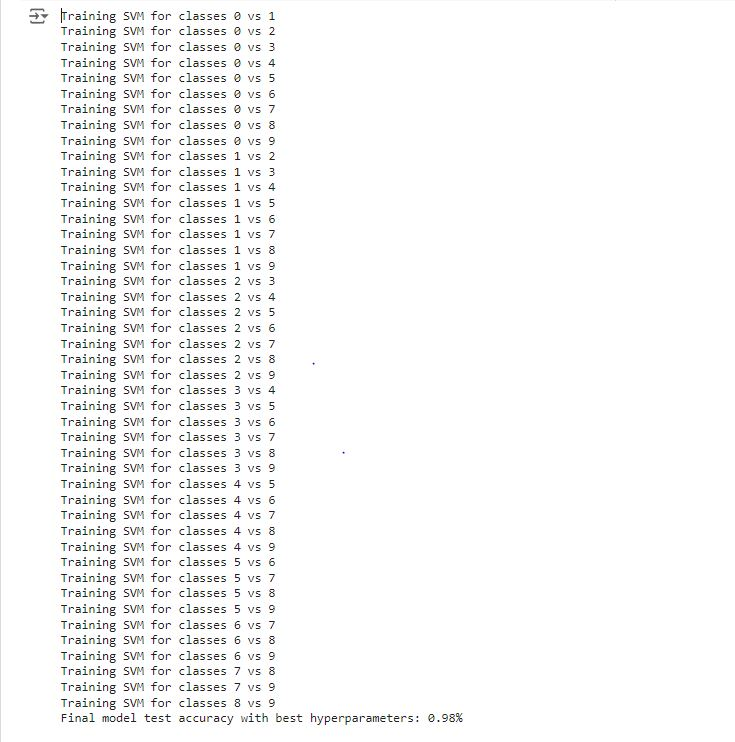

### **Q4** (20 marks) **Ridge Regression and LASSO**

**Part 4.1**  (10 marks) Implement the Ridge regression (both the closed-form solution and SGD) and compare it with [the linear regression method](https://colab.research.google.com/drive/1qMWyoqylJpDEbMwtcSGLZJzhJsOyWW8r) in terms of convergence rate and/or classification accuracy in the binary classification task of digits ('7' and '9') in MNIST.



In [ ]:
# write your code for Q4.1 here

!gdown --folder https://drive.google.com/drive/folders/1r20aRjc2iu9O3kN3Xj9jNYY2uMgcERY1 2> /dev/null

# install python_mnist

!pip install python_mnist

Processing file 1Jf2XqGR7y1fzOZNKLJiom7GmZZUzXhfs t10k-images-idx3-ubyte
Processing file 1qiYu9dW3ZNrlvTFO5fI4qf8Wtr8K-pCu t10k-labels-idx1-ubyte
Processing file 1SnWvBcUETRJ53rEJozFUUo-hOQFPKxjp train-images-idx3-ubyte
Processing file 1kKEIi_pwVHmabByAnwZQsaMgro9XiBFE train-labels-idx1-ubyte


In [ ]:
#load MINST images

from mnist import MNIST
import numpy as np

mnist_loader = MNIST('MNIST')
train_data, train_label = mnist_loader.load_training()
test_data, test_label = mnist_loader.load_testing()
train_data = np.array(train_data, dtype='float')/255 # norm to [0,1]
train_label = np.array(train_label, dtype='short')
test_data = np.array(test_data, dtype='float')/255 # norm to [0,1]
test_label = np.array(test_label, dtype='short')

#add small random noise to avoid matrix singularity
train_data += np.random.normal(0,0.0001,train_data.shape)

print(train_data.shape, train_label.shape, test_data.shape, test_label.shape)

(60000, 784) (60000,) (10000, 784) (10000,)


In [ ]:
# prepare digits '3' and '8' for linear regression

digit_train_index = np.logical_or(train_label == 7, train_label == 9)
X_train = train_data[digit_train_index]
y_train = train_label[digit_train_index]
digit_test_index = np.logical_or(test_label == 7, test_label == 9)
X_test = test_data[digit_test_index]
y_test = test_label[digit_test_index]

# add a constant column of '1' to accomodate the bias (see the margin note on page 107)
X_train = np.hstack((X_train, np.ones((X_train.shape[0], 1), dtype=X_train.dtype)))
X_test = np.hstack((X_test, np.ones((X_test.shape[0], 1), dtype=X_test.dtype)))

# convert labels: '3' => -1, '8' => +1
CUTOFF = 8 # any number between '3' and '8'
y_train = np.sign(y_train-CUTOFF)
y_test = np.sign(y_test-CUTOFF)

print(X_train.shape)
print(y_train)

print(X_test.shape)
print(y_test)

(12214, 785)
[ 1 -1  1 ... -1  1  1]
(2037, 785)
[-1  1  1 ... -1 -1  1]


In [ ]:
# solve linear regression using gradient descent
import numpy as np

class Optimizer():
  def __init__(self, lr, annealing_rate, batch_size, max_epochs, l2_lambda):
    self.lr = lr
    self.annealing_rate = annealing_rate
    self.batch_size = batch_size
    self.max_epochs = max_epochs
    self.l2_lambda = l2_lambda

# X[N,d]: training features; y[N]: training targets;
# X2[N,d]: test features; y2[N]: test targets;
# op: hyper-parameters for optimzer
#
# Note: X2 and y2 are not used in training
#       but only for computting the learning curve B
#
def linear_regression_gd2(X, y, X2, y2, op):
  n = X.shape[0]   # number of samples
  w = np.zeros(X.shape[1])  # initialization

  lr = op.lr
  errorsA = np.zeros(op.max_epochs)
  errorsB = np.zeros(op.max_epochs)
  errorsC = np.zeros(op.max_epochs)

  for epoch in range(op.max_epochs):
    indices = np.random.permutation(n)  #randomly shuffle data indices
    for batch_start in range(0, n, op.batch_size):
      X_batch = X[indices[batch_start:batch_start + op.batch_size]]
      y_batch = y[indices[batch_start:batch_start + op.batch_size]]

      # vectorization to compute gradients for a whole mini-batch (see the above formula)
      w_grad = X_batch.T @ X_batch @ w - X_batch.T @ y_batch + 2 * op.l2_lambda * w

      w -= lr * w_grad / X_batch.shape[0]

    # for learning curve C
    diff = X @ w - y  # prediction difference
    errorsC[epoch] = np.sum(diff*diff)/n

    # for learning curve A
    predict = np.sign(X @ w)
    errorsA[epoch] = np.count_nonzero(np.equal(predict,y))/y.size

    # for learning curve B
    predict2 = np.sign(X2 @ w)
    errorsB[epoch] = np.count_nonzero(np.equal(predict2,y2))/y2.size

    lr *= op.annealing_rate
    print(f'epoch={epoch}: the mean square error is {errorsC[epoch]:.3f} ({errorsA[epoch]:.3f},{errorsB[epoch]:.3f})')

  return w, errorsA, errorsB, errorsC

epoch=0: the mean square error is 0.322 (0.934,0.937)
epoch=1: the mean square error is 0.284 (0.939,0.946)
epoch=2: the mean square error is 0.272 (0.941,0.947)
epoch=3: the mean square error is 0.264 (0.944,0.949)
epoch=4: the mean square error is 0.259 (0.947,0.951)
epoch=5: the mean square error is 0.254 (0.948,0.953)
epoch=6: the mean square error is 0.251 (0.949,0.954)
epoch=7: the mean square error is 0.248 (0.949,0.955)
epoch=8: the mean square error is 0.246 (0.951,0.957)
epoch=9: the mean square error is 0.244 (0.952,0.957)
epoch=10: the mean square error is 0.243 (0.952,0.957)
epoch=11: the mean square error is 0.241 (0.954,0.956)
epoch=12: the mean square error is 0.240 (0.952,0.956)
epoch=13: the mean square error is 0.239 (0.953,0.957)
epoch=14: the mean square error is 0.238 (0.954,0.957)
epoch=15: the mean square error is 0.237 (0.953,0.956)
epoch=16: the mean square error is 0.236 (0.956,0.959)
epoch=17: the mean square error is 0.236 (0.954,0.959)
epoch=18: the mean s

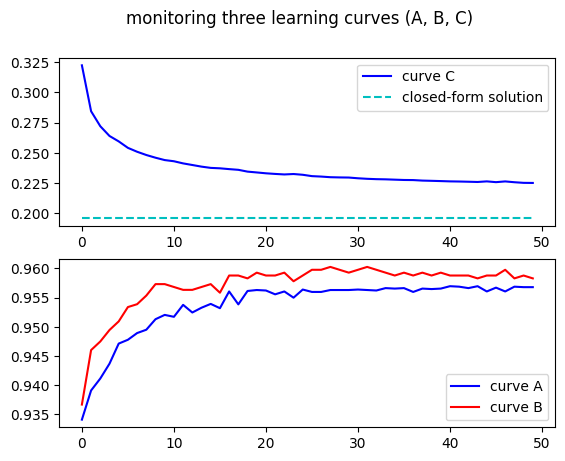

In [ ]:
import matplotlib.pyplot as plt

op = Optimizer(lr=0.0025, annealing_rate=0.99, batch_size=50, max_epochs=50
               , l2_lambda = 0.005)

w, A, B, C = linear_regression_gd2(X_train, y_train, X_test, y_test, op)

fig, ax = plt.subplots(2)
fig.suptitle('monitoring three learning curves (A, B, C)')
ax[0].plot(C, 'b', 0.196*np.ones(C.shape[0]), 'c--')
ax[0].legend(['curve C', 'closed-form solution'])

ax[1].plot(A, 'b', B, 'r')
ax[1].legend(['curve A', 'curve B'])

**Part 4.2** (10 marks) Implement the SGD for LASSO and compare its solution with that of [the linear regression method](https://colab.research.google.com/drive/1qMWyoqylJpDEbMwtcSGLZJzhJsOyWW8r) in the Boston House data set. Discuss your findings.



In [ ]:
# write your code for Q4.2 here

!gdown --folder https://drive.google.com/drive/folders/12L9XNwhIH2wQBa4-IdQrhsrtgRFbeIMZ 2> /dev/null

Processing file 1IZf0tFGW3Zv3Ax5gxKgnklHe1DUI7CAI boston.csv


In [ ]:
import pandas as pd
import numpy as np

raw_data = pd.read_csv('Boston/boston.csv', header=None)
data_rows = np.reshape(raw_data.to_numpy(), (506,14))
data = data_rows[:,:13]
target = data_rows[:,13]

# normalize input features to zero-mean and unit-variance
data = (data-np.mean(data, axis=0))/np.std(data, axis=0)

print(data.shape)
print(target.shape)

(506, 13)
(506,)


In [ ]:
data_wb = np.hstack((data, np.ones((data.shape[0], 1), dtype=data.dtype)))

In [ ]:
# solve linear regression using gradient descent
import numpy as np

class Optimizer():
  def __init__(self, lr, annealing_rate, batch_size, max_epochs, l1_lambda):
    self.lr = lr
    self.annealing_rate = annealing_rate
    self.batch_size = batch_size
    self.max_epochs = max_epochs
    self.l1_lambda = l1_lambda

# X[N,d]: input features; y[N]: output targets; op: hyper-parameters for optimzer
def LASSO_gd(X, y, op):
  n = X.shape[0]   # number of samples
  w = np.zeros(X.shape[1])  # initialization

  lr = op.lr
  errors = np.zeros(op.max_epochs)
  for epoch in range(op.max_epochs):
    indices = np.random.permutation(n)  #randomly shuffle data indices
    for batch_start in range(0, n, op.batch_size):
      X_batch = X[indices[batch_start:batch_start + op.batch_size]]
      y_batch = y[indices[batch_start:batch_start + op.batch_size]]

      # vectorization to compute gradients for a whole mini-batch (see the above formula)
      w_grad = X_batch.T @ X_batch @ w - X_batch.T @ y_batch + op.l1_lambda * np.sign(w)

      w -= lr * w_grad / X_batch.shape[0]

    diff = X @ w - y  # prediction difference
    errors[epoch] = np.sum(diff*diff)/n
    lr *= op.annealing_rate
    #print(f'epoch={epoch}: the mean square error is {errors[epoch]}')

  return w, errors

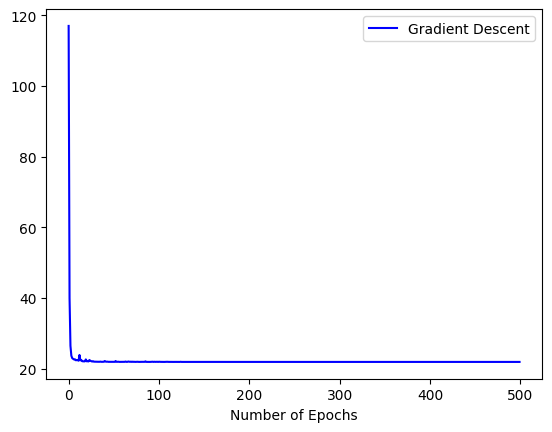

In [ ]:
import matplotlib.pyplot as plt

op = Optimizer(lr=0.05, annealing_rate=0.99, batch_size=30, max_epochs=500, l1_lambda=0.05)

w, errors = LASSO_gd(data_wb, target, op)

plt.xlabel('Number of Epochs')
plt.plot(errors, 'b', label='Gradient Descent')
plt.legend()
plt.show()